In [2]:
from river import datasets
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [3]:
print(datasets.Elec2().desc)

Electricity prices in New South Wales.

This is a binary classification task, where the goal is to predict if the price of electricity
will go up or down.

This data was collected from the Australian New South Wales Electricity Market. In this market,
prices are not fixed and are affected by demand and supply of the market. They are set every
five minutes. Electricity transfers to/from the neighboring state of Victoria were done to
alleviate fluctuations.


In [4]:
list(datasets.Elec2().take(2))

[({'date': 0.0,
   'day': 2,
   'period': 0.0,
   'nswprice': 0.056443,
   'nswdemand': 0.439155,
   'vicprice': 0.003467,
   'vicdemand': 0.422915,
   'transfer': 0.414912},
  True),
 ({'date': 0.0,
   'day': 2,
   'period': 0.021277,
   'nswprice': 0.051699,
   'nswdemand': 0.415055,
   'vicprice': 0.003467,
   'vicdemand': 0.422915,
   'transfer': 0.414912},
  True)]

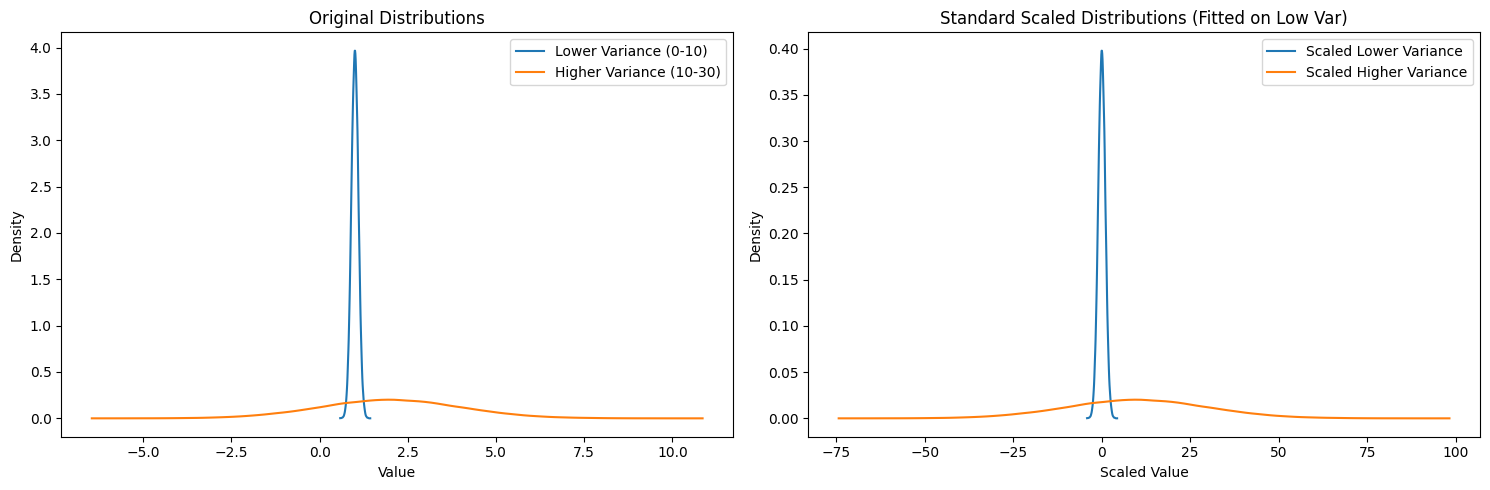

In [5]:

# Generate artificial Gaussian data
dist_low = np.random.normal(loc=1, scale=0.1, size=100000)
dist_high = np.random.normal(loc=2, scale=2, size=100000)

# Apply standard scaling based on dist_low
scaler = StandardScaler()
dist_low_scaled = scaler.fit_transform(dist_low.reshape(-1, 1)).flatten()
dist_high_scaled = scaler.transform(dist_high.reshape(-1, 1)).flatten()

# Plotting the distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Original distributions
for dist, label in [(dist_low, 'Lower Variance (0-10)'), (dist_high, 'Higher Variance (10-30)')]:
    kde = gaussian_kde(dist)
    x = np.linspace(dist.min(), dist.max(), 100)
    ax1.plot(x, kde(x), label=label)
ax1.set_title('Original Distributions')
ax1.set_xlabel('Value')
ax1.set_ylabel('Density')
ax1.legend()

# Scaled distributions
for dist, label in [(dist_low_scaled, 'Scaled Lower Variance'), (dist_high_scaled, 'Scaled Higher Variance')]:
    kde = gaussian_kde(dist)
    x = np.linspace(dist.min(), dist.max(), 100)
    ax2.plot(x, kde(x), label=label)
ax2.set_title('Standard Scaled Distributions (Fitted on Low Var)')
ax2.set_xlabel('Scaled Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

$scaled \mu_{post} = \frac{\mu_{post} - \mu_{pre}}{\sigma_{pre}}$


$scaled \sigma_{post} = \frac{\sigma_{post}}{\sigma_{pre}}$

In [6]:
print("Pre Scaling | Post Scaling")
print(f"mean low: {dist_low.mean():.2f} | {dist_low_scaled.mean():.2f}")
print(f"std low: {dist_low.std():.2f} | {dist_low_scaled.std():.2f}\n")

print(f"mean high: {dist_high.mean():.2f} | {dist_high_scaled.mean():.2f}")
print(f"std high: {dist_high.std():.2f} | {dist_high_scaled.std():.2f}\n")

print("Difference Pre Scaling | Difference Post Scaling")
print(f"mean: {dist_high.mean() - dist_low.mean():.2f} | {dist_high_scaled.mean() - dist_low_scaled.mean():.2f}")
print(f"std: {dist_high.std() - dist_low.std():.2f} | {dist_high_scaled.std() - dist_low_scaled.std():.2f}")


Pre Scaling | Post Scaling
mean low: 1.00 | -0.00
std low: 0.10 | 1.00

mean high: 2.00 | 9.95
std high: 2.00 | 19.95

Difference Pre Scaling | Difference Post Scaling
mean: 1.00 | 9.95
std: 1.90 | 18.95


In [7]:
print("Pre Scaling | Post Scaling")
print(f"mean low: {dist_low.mean():.2f} | {dist_low_scaled.mean():.2f}")
print(f"std low: {dist_low.std():.2f} | {dist_low_scaled.std():.2f}\n")

print(f"mean high: {dist_high.mean():.2f} | {dist_high_scaled.mean():.2f}")
print(f"std high: {dist_high.std():.2f} | {dist_high_scaled.std():.2f}\n")

print("Difference Pre Scaling | Difference Post Scaling")
print(f"mean: {dist_high.mean() - dist_low.mean():.2f} | {dist_high_scaled.mean() - dist_low_scaled.mean():.2f}")
print(f"std: {dist_high.std() - dist_low.std():.2f} | {dist_high_scaled.std() - dist_low_scaled.std():.2f}")


Pre Scaling | Post Scaling
mean low: 1.00 | -0.00
std low: 0.10 | 1.00

mean high: 2.00 | 9.95
std high: 2.00 | 19.95

Difference Pre Scaling | Difference Post Scaling
mean: 1.00 | 9.95
std: 1.90 | 18.95


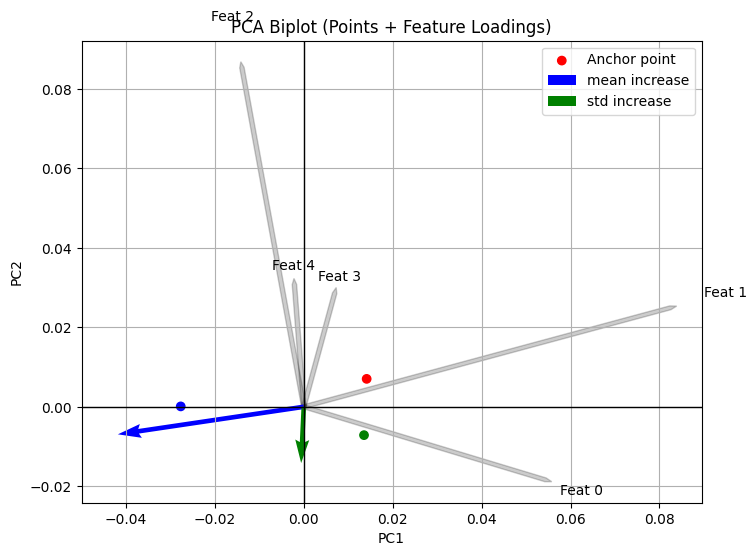

In [11]:
X = np.array([
    [ 0.,          0.,          0.,          0.,          0.        ],
    [-0.02146485, -0.03621045, -0.00008458, -0.00487769, -0.00124969],
    [ 0.00227543, -0.00401705, -0.01199411, -0.00408222, -0.00434468]
])
# X = np.array([
#     [ 0.,          0.,          0.,          0.,          0.        ],
#     [-0.0, 0.03621045, -0.0, -0.004, -0.0],
#     [ 0.00227543, -0.004, -0.01199411, -0.00408222, -0.00434468]
# ])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

colors = ['red', 'blue', 'green']
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, label='Anchor point')

# loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings = pca.components_.T 

# We have 5 features, so we plot 5 arrows
feature_names = ['Feat 0', 'Feat 1', 'Feat 2', 'Feat 3', 'Feat 4']

for i, feature_vec in enumerate(loadings):
    # We multiply by a scale factor to make the arrows visible relative to data
    scale = 0.1

    # Loadings starting from anchor point - visually more clear?
    # plt.arrow(X_pca[0, 0], X_pca[0, 1], feature_vec[0]*scale, feature_vec[1]*scale, 
    #           color='black', alpha=0.2, head_width=0.001)
    # plt.text(X_pca[0, 0]+feature_vec[0]*scale*1.15, X_pca[0, 1]+feature_vec[1]*scale*1.15, 
    #          feature_names[i], color='black', ha='center', va='center')

    # Loadings starting from PCA 0.0 - correct?
    plt.arrow(0, 0, feature_vec[0]*scale, feature_vec[1]*scale, 
              color='black', alpha=0.2, head_width=0.001)
    plt.text(feature_vec[0]*scale*1.15, feature_vec[1]*scale*1.15, 
             feature_names[i], color='black', ha='center', va='center')

labels = ["mean increase", "std increase"]
for i, label in enumerate(labels):
    # Arrows starting from transformed anchor point (Correct?)
    # plt.quiver(X_pca[0, 0], X_pca[0, 1], X_pca[i+1, 0]-X_pca[0, 0], X_pca[i+1, 1]-X_pca[0, 1], color=colors[i+1], angles='xy', scale_units='xy', scale=1, label=label)
    
    # Arrows with angles as above shifted to 0.0
    plt.quiver(0,0, (X_pca[i+1, 0]-X_pca[0, 0]), (X_pca[i+1, 1]-X_pca[0, 1]), color=colors[i+1], angles='xy', scale_units='xy', scale=1, label=label)

    # Arrows starting at 0.0 - gives alignment I would expect when manipulating data
    # plt.quiver(0,0, X_pca[i+1, 0], X_pca[i+1, 1], color=colors[i+1], angles='xy', scale_units='xy', scale=1, label=label)

plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot (Points + Feature Loadings)')
plt.grid(True)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.xlim(left = -0.05)
plt.show()